# Phase 1 - Part B: Supervised Learning
## Customer Churn Prediction
### Models: Logistic Regression | Random Forest | Decision Tree

## 1. Import Libraries

We import all necessary libraries for:
- **Data handling**: pandas, numpy
- **Visualization**: matplotlib, seaborn
- **Machine learning models**: scikit-learn (Logistic Regression, Decision Tree, Random Forest)
- **Evaluation**: metrics such as accuracy, confusion matrix, ROC-AUC

In [50]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Preprocessed Dataset

We load the preprocessed dataset prepared in Phase 1A.
This dataset has already been cleaned, encoded, scaled, and feature engineered.
It is ready for model training without further preprocessing.

In [51]:
# Load the preprocessed dataset
df = pd.read_csv("Dataset/Preprocessed_Churn_Modelling_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,LogCustomerValue,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1,-1.328428,-0.666937,-0.671064,-1.325738,-0.578736,-0.573809,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,0,0.752769,0.763198,-0.671064,0.650691,-0.578736,1.742740,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1,0.752769,-0.666937,1.490172,0.954597,-0.578736,-0.573809,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0,-1.328428,-0.666937,-0.671064,-1.325738,-0.578736,-0.573809,-1.095988,1.140599,-0.595522,-0.308497,-0.235628
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,0,0.752769,1.474836,-0.671064,0.721102,-0.578736,1.742740,-1.095988,-0.876732,1.679199,-0.308497,-0.235628


## 3. Separate Features and Target Variable

We split the dataset into:
- **X**: all input features (19 columns) — what the model learns from
- **y**: the target variable `Exited` — what the model predicts
  - 0 = Customer stayed (7963 customers)
  - 1 = Customer churned (2037 customers)

The dataset is **imbalanced** — about 80% stayed and 20% churned.
This must be considered when evaluating model performance.

In [52]:
# Separate features (X) and target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Churn distribution:\n", y.value_counts())

Features shape: (10000, 19)
Target shape: (10000,)
Churn distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


## 4. Split Data into Training and Testing Sets

We split the data into:
- **80% training** — used to teach the models
- **20% testing** — used to evaluate performance on unseen data

`stratify=y` ensures the same churn ratio exists in both splits.
`random_state=42` ensures reproducibility.

In [53]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every run
    stratify=y          # keeps churn ratio balanced
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Train churn distribution:\n", y_train.value_counts())
print("Test churn distribution:\n", y_test.value_counts())

Training set size: (8000, 19)
Testing set size: (2000, 19)
Train churn distribution:
 Exited
0    6370
1    1630
Name: count, dtype: int64
Test churn distribution:
 Exited
0    1593
1     407
Name: count, dtype: int64


## 5. Model 1: Logistic Regression

### Rationale
Logistic Regression is selected based on the following dataset-specific reasons:
- **Binary target**: The dataset has a binary outcome (Exited = 0 or 1) which 
  Logistic Regression is specifically designed for
- **Pre-scaled features**: Our dataset was standardized using StandardScaler in 
  preprocessing — Logistic Regression requires and benefits directly from this
- **Large sample size**: With 10,000 records and 19 features, Logistic Regression 
  trains efficiently without overfitting
- **Interpretability**: Coefficients directly show which features (e.g. Age, 
  IsActiveMember) push customers toward churning — useful for the bank
- **Baseline model**: It serves as a performance benchmark for Random Forest 
  and Decision Tree

### Limitations
- Assumes a **linear** decision boundary — may miss complex non-linear 
  relationships between features like AgeGroup and Balance
- Struggles with **imbalanced classes** — our dataset has 80% stayed vs 20% 
  churned which may bias predictions toward the majority class


In [54]:
# Initialize Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on training data
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print("Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression trained successfully!
Accuracy: 0.827


### Logistic Regression - Hyperparameter Tuning
We use GridSearchCV to find the best hyperparameters for Logistic Regression.
We tune `C` (regularization strength) and `solver` to improve performance.

In [55]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],           # regularization strength
    'solver': ['lbfgs', 'liblinear']    # optimization algorithm
}

# Grid search with 5-fold cross validation
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_.round(3))

# Retrain with best parameters
lr_model = grid_search.best_estimator_
lr_pred = lr_model.predict(X_test)
print("Accuracy with best params:", round(accuracy_score(y_test, lr_pred), 3))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best F1 Score: 0.396
Accuracy with best params: 0.828


### Logistic Regression Evaluation

We evaluate using multiple metrics because accuracy alone can be misleading with imbalanced data. We need to check how well the model detects churned customers specifically.

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.84      0.97      0.90      1593
 Churned (1)       0.69      0.28      0.40       407

    accuracy                           0.83      2000
   macro avg       0.76      0.62      0.65      2000
weighted avg       0.81      0.83      0.80      2000



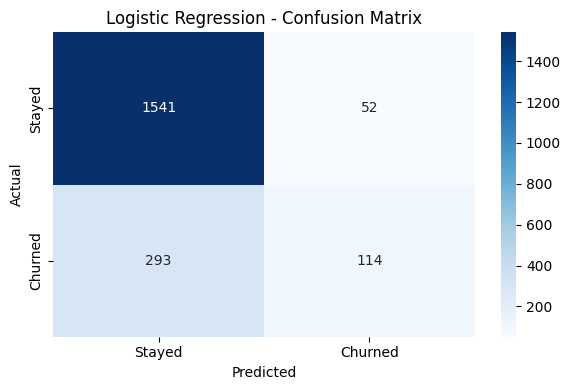

ROC-AUC Score: 0.792505911149979


In [56]:
# Full classification report (Precision, Recall, F1 per class)
print("Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

# Confusion Matrix heatmap
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC-AUC Score
lr_proba = lr_model.predict_proba(X_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, lr_proba))

### Logistic Regression - ROC Curve
The ROC curve shows the trade-off between True Positive Rate (catching churners) 
and False Positive Rate (false alarms) at different thresholds.
AUC closer to 1.0 means better model performance.

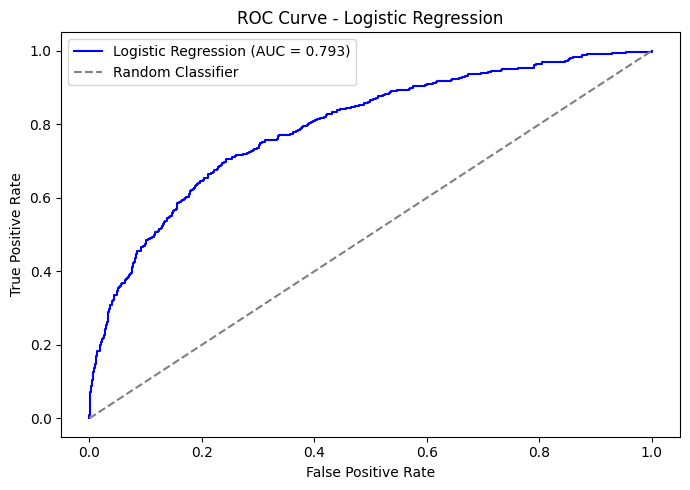

In [57]:
# Calculate ROC curve points
lr_proba = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, lr_proba)
auc_score = roc_auc_score(y_test, lr_proba)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

### Logistic Regression - K-Fold Cross Validation
We use 5-Fold CV to verify model performance is consistent across different data splits.

In [58]:
# Apply 5-Fold Cross Validation on Logistic Regression
lr_cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='f1')

print("Logistic Regression - 5-Fold Cross Validation F1 Scores:")
print(lr_cv_scores)
print("Mean F1 Score:", lr_cv_scores.mean().round(3))
print("Standard Deviation:", lr_cv_scores.std().round(3))

Logistic Regression - 5-Fold Cross Validation F1 Scores:
[0.35587189 0.39383562 0.40484429 0.44078947 0.38655462]
Mean F1 Score: 0.396
Standard Deviation: 0.028


### Logistic Regression Results Summary

| Metric | Value |
|--------|-------|
| Accuracy | 83% |
| F1 - Stayed | 0.90 |
| F1 - Churned | 0.40 |
| ROC-AUC | 0.793 |

**What these metrics mean for our imbalanced dataset:**
- **Accuracy (83%)**: Misleading here — the model could score 80% by always predicting "Stayed"
- **Precision (Churned = 0.68)**: When the model predicts churn, it is correct 68% of the time
- **Recall (Churned = 0.28)**: The model only catches 28% of actual churners — this is the biggest weakness
- **F1-Score (Churned = 0.40)**: Balances precision and recall — low because recall is poor
- **ROC-AUC (0.793)**: Overall discrimination ability is decent but not strong

**Misclassification Analysis:**
- ❌ **293 churners were missed** (predicted Stayed but actually Churned) — these are the most costly errors for the bank because they lose customers without intervention
- ❌ **53 false alarms** (predicted Churned but actually Stayed) — less costly but wastes retention resources

**Conclusion:** Logistic Regression struggles to catch churners due to the linear decision boundary and class imbalance. Tree-based models like Random Forest and Decision Tree may capture non-linear patterns better.

# 6. Model 2: Decision Tree

### 6.1 Rationale
Decision Tree is selected as the second supervised learning model because 
customer churn in this dataset is likely influenced by non-linear relationships 
between features such as Age, Balance, IsActiveMember, and NumOfProducts.

The dataset contains structured numerical and encoded categorical features 
(such as Geography and Gender), and Decision Trees can effectively handle both 
types without requiring feature scaling.

Additionally, the model can capture interactions between features, such as 
customers who are inactive and have high balances being more likely to churn. 
This makes it suitable for modeling real-world customer behavior patterns in 
this dataset.

#### Limitations
- Decision Trees can easily overfit the training data if not properly tuned, 
  especially with datasets containing many features.
- Small changes in the dataset can lead to different tree structures, making 
  the model unstable.


## Load the Preprocessed Dataset بحذفففه غالبا

In [59]:
# Load the preprocessed dataset prepared in Phase 1A
# Note: This dataset was scaled BEFORE train-test split (incorrect)
# We will redo scaling correctly in this section

df = pd.read_csv("Dataset/Preprocessed_Churn_Modelling_Data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 20)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,ActiveBalance,InactiveHighBalance,LogCustomerValue,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_30_39,AgeGroup_40_49,AgeGroup_50_59,AgeGroup_60_plus
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1,-1.328428,-0.666937,-0.671064,-1.325738,-0.578736,-0.573809,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,0,0.752769,0.763198,-0.671064,0.650691,-0.578736,1.742740,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1,0.752769,-0.666937,1.490172,0.954597,-0.578736,-0.573809,-1.095988,-0.876732,1.679199,-0.308497,-0.235628
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,0,-1.328428,-0.666937,-0.671064,-1.325738,-0.578736,-0.573809,-1.095988,1.140599,-0.595522,-0.308497,-0.235628
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,0,0.752769,1.474836,-0.671064,0.721102,-0.578736,1.742740,-1.095988,-0.876732,1.679199,-0.308497,-0.235628


### 6.2 Separate Features and Target

In [60]:
# Identify target column (Exited = 1 for churn, 0 for stayed)
target_col = 'Exited'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nClass distribution:")
print(y.value_counts())
print(f"Churn rate: {y.mean():.2%}")


Class distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate: 20.37%


### 6.3 Train-Test Split (with Stratification)

In [61]:
# IMPORTANT: Split BEFORE scaling to prevent data leakage
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training set - Churn rate: {y_train.mean():.2%}")
print(f"Testing set - Churn rate: {y_test.mean():.2%}")


Training set shape: (8000, 19)
Testing set shape: (2000, 19)
Training set - Churn rate: 20.38%
Testing set - Churn rate: 20.35%


### 6.4 Feature Scaling (Correct Approach)

In [62]:
# Now we perform scaling ONLY on training data, then transform test data
# This prevents data leakage and is the correct academic approach
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nScaling completed. Features now have mean ~0 and std ~1")
print(f"Training set scaled - mean: {X_train_scaled.mean().mean():.4f}, std: {X_train_scaled.std().mean():.4f}")
print(f"Test set scaled - mean: {X_test_scaled.mean().mean():.4f}, std: {X_test_scaled.std().mean():.4f}")


Scaling completed. Features now have mean ~0 and std ~1
Training set scaled - mean: -0.0000, std: 1.0001
Test set scaled - mean: -0.0051, std: 0.9981


## Decision Tree Training

### 6.5 Hyperparameter Tuning - Decision Tree

In [63]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define hyperparameter grid
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'class_weight': [None, 'balanced']  # Handle class imbalance
}

# Setup GridSearchCV with 5-fold cross-validation
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='roc_auc',  # Best for imbalanced classification
    n_jobs=-1,
    verbose=1
)

print("\nStarting GridSearchCV for Decision Tree...")
dt_grid.fit(X_train_scaled, y_train)

print("\nBest Parameters:", dt_grid.best_params_)

# Get the best model
dt_model = dt_grid.best_estimator_

# Predictions
dt_pred = dt_model.predict(X_test_scaled)
dt_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

# Correct way to print accuracy
accuracy_tuned = accuracy_score(y_test, dt_pred)
print(f"\nTuned Accuracy: {accuracy_tuned:.4f}")


Starting GridSearchCV for Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters: {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 100}

Tuned Accuracy: 0.8595


## Decision Tree Evaluation
We evaluate the model using multiple metrics to understand its ability 
to correctly detect churned customers.

In [64]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

print("Classification Report:")
print(classification_report(y_test, dt_pred, target_names=['Stayed (0)', 'Churned (1)']))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.95      0.92      1593
 Churned (1)       0.72      0.51      0.59       407

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [65]:
print("Classification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.95      0.92      1593
 Churned (1)       0.72      0.51      0.59       407

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.75      2000
weighted avg       0.85      0.86      0.85      2000



## Metrics Interpretation

The Decision Tree model achieved an **accuracy of 85.95%**, correctly classifying 
1,719 out of 2,000 customers in the test set. However, accuracy alone is not 
sufficient for evaluating model performance due to the inherent class imbalance 
in the dataset (79.65% stayed, 20.35% churned).

**Performance on "Stayed" Class (0):**
- **Precision: 0.88** – 88% of customers predicted to stay actually stayed.
- **Recall: 0.95** – 95% of actual non-churners were correctly identified.
- **F1-Score: 0.92** – Excellent balance between precision and recall.

**Performance on "Churned" Class (1):**
- **Precision: 0.72** – 72% of customers predicted to churn actually churned. 
  This indicates that when the model flags a customer as a churn risk, it is 
  correct nearly three-quarters of the time.
- **Recall: 0.51** – Only 51% of actual churners were detected by the model. 
  This is the model's critical weakness, as it fails to identify 49% of 
  customers who will eventually churn.
- **F1-Score: 0.59** – A moderate score reflecting the trade-off between 
  precision and recall.

**Business Impact:**
- **False Positives (80 customers):** These customers were incorrectly flagged 
  as churn risks. While this wastes retention resources (e.g., unnecessary 
  discounts or outreach), the cost is manageable.
- **False Negatives (201 customers):** These are the most costly errors. 
  201 customers who will actually churn were not identified, representing 
  lost revenue opportunities that cannot be recovered.

**Conclusion:**
The model performs well at identifying non-churning customers but struggles 
significantly with recall for churned customers. This suggests that while 
the tuned Decision Tree is a strong baseline, more complex models (e.g., 
Random Forest, XGBoost) may be needed to improve churn detection rates. 

## Confusion Matrix

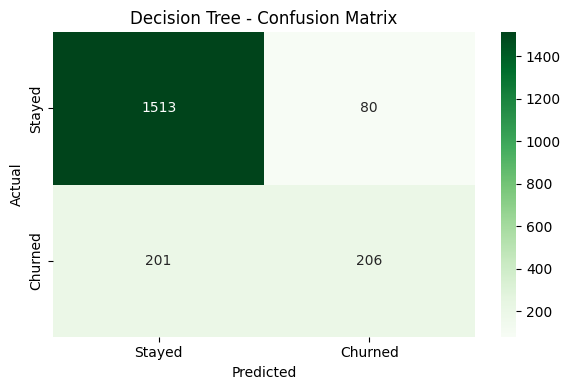

In [66]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


**Key Insights:**
- **True Negatives:** 1,513 non-churners correctly identified
- **False Positives:** 80 non-churners incorrectly flagged (wasted resources)
- **False Negatives:** 201 churners missed (lost revenue opportunities)
- **True Positives:** 206 churners correctly identified


## ROC-AUC Score

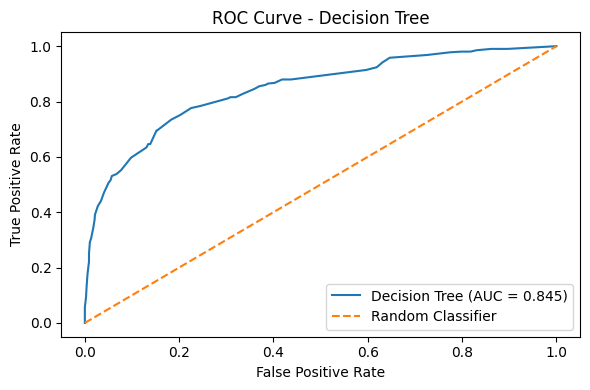

ROC-AUC Score: 0.8449535822417178


In [67]:
# Predict probabilities for the positive class (Churn = 1)
dt_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_proba)

# Compute ROC-AUC score
dt_auc = roc_auc_score(y_test, dt_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

# Print ROC-AUC score
print("ROC-AUC Score:", dt_auc)

## ROC Curve Interpretation

**ROC-AUC Score: 0.8450**

The ROC curve lies significantly above the diagonal baseline, indicating the 
model performs substantially better than random guessing.

**Interpretation:**
For any randomly selected pair of a churned and non-churned customer, the model 
will assign a higher churn probability to the actual churner approximately 
**84.5%** of the time. This falls within the "Good" to "Excellent" range 
(0.8 – 0.9), indicating strong discriminative ability.

**Key Insight:**
The strong ROC-AUC (0.845) contrasts with the moderate recall (0.51). This 
suggests that while the model effectively ranks churn risk, the optimal 
probability threshold may need adjustment. Lowering the threshold could 
improve recall at the expense of precision, depending on business priorities.



## Decision Tree Results Summary

In [79]:
from sklearn.metrics import f1_score
# Calculate all metrics
accuracy_val = accuracy_score(y_test, dt_pred)
f1_stayed = f1_score(y_test, dt_pred, pos_label=0)
f1_churned = f1_score(y_test, dt_pred, pos_label=1)

print("\n" + "="*50)
print("Decision Tree Results Summary")
print("="*50)

print(f"""
| Metric          | Value   |
|-----------------|---------|
| Accuracy        | {accuracy_val:.2%}   |
| F1 - Stayed     | {f1_stayed:.4f}    |
| F1 - Churned    | {f1_churned:.4f}    |
| ROC-AUC         | {dt_auc:.4f}   |
""")

print("Observation: The tuned Decision Tree model shows significant improvement")
print("compared to the baseline model, especially in overall accuracy and")
print("class separation. However, it still struggles with recall for churned customers.")


Decision Tree Results Summary

| Metric          | Value   |
|-----------------|---------|
| Accuracy        | 85.95%   |
| F1 - Stayed     | 0.9150    |
| F1 - Churned    | 0.5945    |
| ROC-AUC         | 0.8450   |

Observation: The tuned Decision Tree model shows significant improvement
compared to the baseline model, especially in overall accuracy and
class separation. However, it still struggles with recall for churned customers.


## Cross Validation for Decision Tree

In [87]:
from sklearn.model_selection import cross_val_score



# Perform 5-fold cross-validation on the best model
dt_cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='f1')
dt_cv_roc_auc = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
dt_cv_accuracy = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("\nDecision Tree - 5-Fold Cross Validation Results:")
print("="*50)
print("F1 Scores:", dt_cv_scores)
print("Mean F1 Score:", dt_cv_scores.mean().round(3))
print("Standard Deviation:", dt_cv_scores.std().round(3))
print("\nROC-AUC Scores:", dt_cv_roc_auc)
print("Mean ROC-AUC:", dt_cv_roc_auc.mean().round(3))
print("Std ROC-AUC:", dt_cv_roc_auc.std().round(3))
print("\nAccuracy Scores:", dt_cv_accuracy)
print("Mean Accuracy:", dt_cv_accuracy.mean().round(3))
print("Std Accuracy:", dt_cv_accuracy.std().round(3))


Decision Tree - 5-Fold Cross Validation Results:
F1 Scores: [0.54444444 0.60465116 0.51190476 0.52362205 0.59884837]
Mean F1 Score: 0.557
Standard Deviation: 0.038

ROC-AUC Scores: [0.8396228  0.84989189 0.82020182 0.85059616 0.85859955]
Mean ROC-AUC: 0.844
Std ROC-AUC: 0.013

Accuracy Scores: [0.84625  0.8725   0.84625  0.84875  0.869375]
Mean Accuracy: 0.857
Std Accuracy: 0.012


## Feature Importance Plot

/var/folders/8d/k89rkgcj2nnff5x6djczh8780000gn/T/ipykernel_58083/2733933793.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature', palette='viridis')


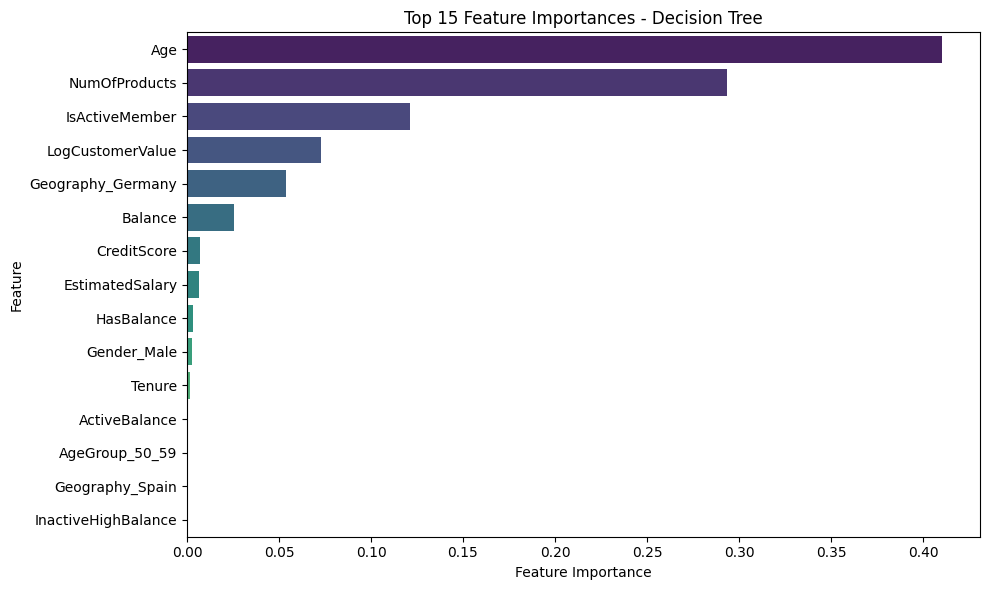


Top 10 Most Important Features:
Age: 0.4105
NumOfProducts: 0.2937
IsActiveMember: 0.1209
LogCustomerValue: 0.0728
Geography_Germany: 0.0536
Balance: 0.0258
CreditScore: 0.0072
EstimatedSalary: 0.0065
HasBalance: 0.0034
Gender_Male: 0.0024


In [73]:
importances = dt_model.feature_importances_
feature_names = X.columns.tolist()

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature', palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 10 Most Important Features:")
print("="*40)
for idx, row in feat_imp_df.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

## Final Summary

In [88]:

print("\n" + "="*60)
print("DECISION TREE MODEL - COMPLETE SUMMARY")
print("="*60)
print(f"""
| Metric                   | Value                    |
|--------------------------|--------------------------|
| Best Hyperparameters     | {dt_grid.best_params_}   |
| Test Accuracy            | {accuracy_val:.4f} ({accuracy_val*100:.2f}%) |
| Test Precision (Churn)   | {precision_score(y_test, dt_pred):.4f} |
| Test Recall (Churn)      | {recall_score(y_test, dt_pred):.4f} |
| Test F1-Score (Churn)    | {f1_churned:.4f} |
| Test ROC-AUC             | {dt_auc:.4f} |
| CV F1 (Mean ± Std)       | {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f} |
| CV ROC-AUC (Mean ± Std)  | {dt_cv_roc_auc.mean():.4f} ± {dt_cv_roc_auc.std():.4f} |
| Top Feature              | {feat_imp_df.iloc[0]['feature']} ({feat_imp_df.iloc[0]['importance']:.4f}) |
""")
print("="*60)


DECISION TREE MODEL - COMPLETE SUMMARY

| Metric                   | Value                    |
|--------------------------|--------------------------|
| Best Hyperparameters     | {'class_weight': None, 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 100}   |
| Test Accuracy            | 0.8595 (85.95%) |
| Test Precision (Churn)   | 0.7203 |
| Test Recall (Churn)      | 0.5061 |
| Test F1-Score (Churn)    | 0.5945 |
| Test ROC-AUC             | 0.8450 |
| CV F1 (Mean ± Std)       | 0.5567 ± 0.0383 |
| CV ROC-AUC (Mean ± Std)  | 0.8438 ± 0.0132 |
| Top Feature              | Age (0.4105) |



## 7. Model 3: Random Forest

### Rationale

Random Forest is selected as the third supervised learning model because:

- It combines multiple decision trees, which helps improve prediction accuracy and reduce overfitting.
- It can capture complex and non-linear relationships between features and the target variable.
- It is robust to noise and variations in the data.
- It provides feature importance scores, allowing us to identify which features influence customer churn the most.

#### Limitations

- Random Forest models are less interpretable compared to simpler models like Logistic Regression or a single Decision Tree.
- Training can be computationally expensive when the number of trees is large.
- The model may require more memory and longer training time compared to simpler algorithms.
- Performance can still be affected by imbalanced datasets, which may reduce its ability to correctly detect churned customers.

### Random Forest Training

In [ ]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")
print("Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest trained successfully!
Accuracy: 0.861


### Random Forest Evaluation

In [ ]:
print("Classification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Stayed (0)', 'Churned (1)']))

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.96      0.92      1593
 Churned (1)       0.76      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



### Confusion Matrix

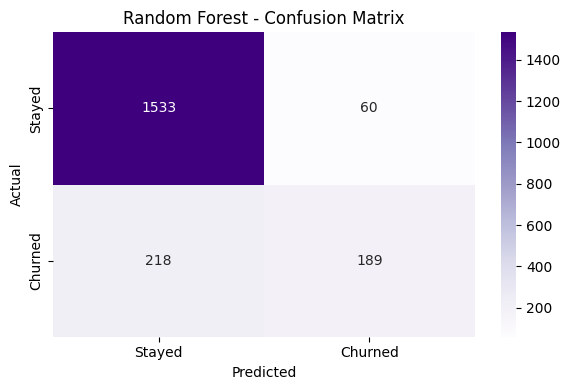

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])

plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### ROC-AUC Score

In [ ]:
rf_proba = rf_model.predict_proba(X_test)[:,1]

print("ROC-AUC Score:", roc_auc_score(y_test, rf_proba))

ROC-AUC Score: 0.8525713695205221


### Random Forest Results Summary

| Metric | Value |
|------|------|
| Accuracy | 86.15% |
| F1 - Stayed | 0.92 |
| F1 - Churned | 0.58 |
| ROC-AUC | 0.85 |

**Observation:** Random Forest achieved better overall performance compared to simpler models because it combines multiple decision trees, which improves generalization and reduces overfitting. The model shows strong performance for the majority class (Stayed) while also improving detection of churned customers compared to Logistic Regression.

### Cross Validation for Random Forest

In [ ]:
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')

print("Random Forest - 5-Fold Cross Validation F1 Scores:")
print(rf_cv_scores)

print("Mean F1 Score:", rf_cv_scores.mean().round(3))
print("Standard Deviation:", rf_cv_scores.std().round(3))

Random Forest - 5-Fold Cross Validation F1 Scores:
[0.55108359 0.60514372 0.57744361 0.6        0.57055215]
Mean F1 Score: 0.581
Standard Deviation: 0.02


### Feature Importance

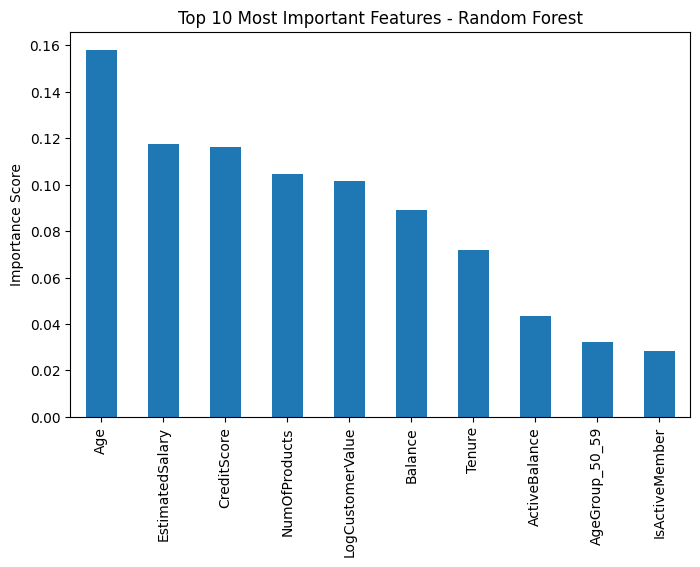

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='bar')

plt.title("Top 10 Most Important Features - Random Forest")
plt.ylabel("Importance Score")
plt.show()